# Importing data and required packages 
Importing pandas , numpy , Matplotlib, Seaborn , Warnings Library 

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [ ]:

plt.style.use('default') # for better visualization

In [35]:
import seaborn as sns

sns.set_style("whitegrid")

Importing the CSV data as pandas dataframe 

In [42]:
df = pd.read_csv('/Users/himanshuberi/Desktop/GITHUB_PROJECTS/Generic_ML_Project/notebook/data/StudentsPerformance.csv')

Showing top 5 records 

In [8]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Shape of the dataset 

In [10]:
df.shape

(1000, 8)

# Data Checks to perform 
1. Check missing value 
2. checking any duplicate values 
3. Checking the datatype 
4. Checking the number of unique values of each columns 
5. Checking the stats of dataset 
6. Check various categories present in the different categorical column 

In [12]:
# Checking for missing value
df.isnull().sum()

# After checking for missing values : there is no missing value in the dataset 

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [15]:
# Checking for duplicate values
df.duplicated().sum()
# After checking for duplicate values : there is no duplicate value in the dataset 

np.int64(0)

Checking the datatype 

In [16]:
# Checking the null and datatypes 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


Checking the number of unque values for each columns 

In [17]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [18]:
# Check the stats of the dataset 
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [21]:
# Exploring data 
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [23]:
print("Categories in 'gender' Variable:",end = " ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' Variable:",end = " ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' Variable:",end = " ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' Variable:",end = " ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' Variable:",end = " ")
print(df['test preparation course'].unique())


Categories in 'gender' Variable: <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' Variable: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental level of education' Variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' Variable: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' Variable: <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [28]:
# Define the numerical and categorical fatures ;
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

# Print the columns 
print('we have {} numerical features {}'.format(len(numerical_features), numerical_features))
print('\nwe have {} categorical features {}'.format(len(categorical_features), categorical_features))

we have 3 numerical features ['math score', 'reading score', 'writing score']

we have 5 categorical features ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


Adding columns for "Total_Score" and "Average" 

In [30]:
df['Total Score'] = df['math score'] + df['reading score'] + df['writing score']
df['Average Score'] = df['Total Score'] / 3
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [32]:
reading_full = df[df['reading score'] == 100]['Average Score'].count()
print("Number of students with full reading score:", reading_full)

writing_full = df[df['writing score'] == 100]['Average Score'].count()
print("Number of students with full writing score:", writing_full)

math_full = df[df['math score'] == 100]['Average Score'].count()
print("Number of students with full math score:", math_full)


Number of students with full reading score: 17
Number of students with full writing score: 14
Number of students with full math score: 7


In [ ]:
reading_less_than_20 = df[df['reading score'] <= 20]['Average Score'].count()
print("Number of students with reading score less than 20:", reading_less_than_20)          

writing_less_than_20 = df[df['writing score'] <= 20]['Average Score'].count()
print("Number of students with writing score less than 20:", writing_less_than_20)

math_less_than_20 = df[df['math score'] <= 20]['Average Score'].count()
print("Number of students with math score less than 20:", math_less_than_20)

Number of students with reading score less than 20: 1
Number of students with writing score less than 20: 3
Number of students with math score less than 20: 4


# Insights : 
1. from above values we get students have performed the worst in maths 
2. Best Performance is in reading section 

# Exploring Data Visualization:


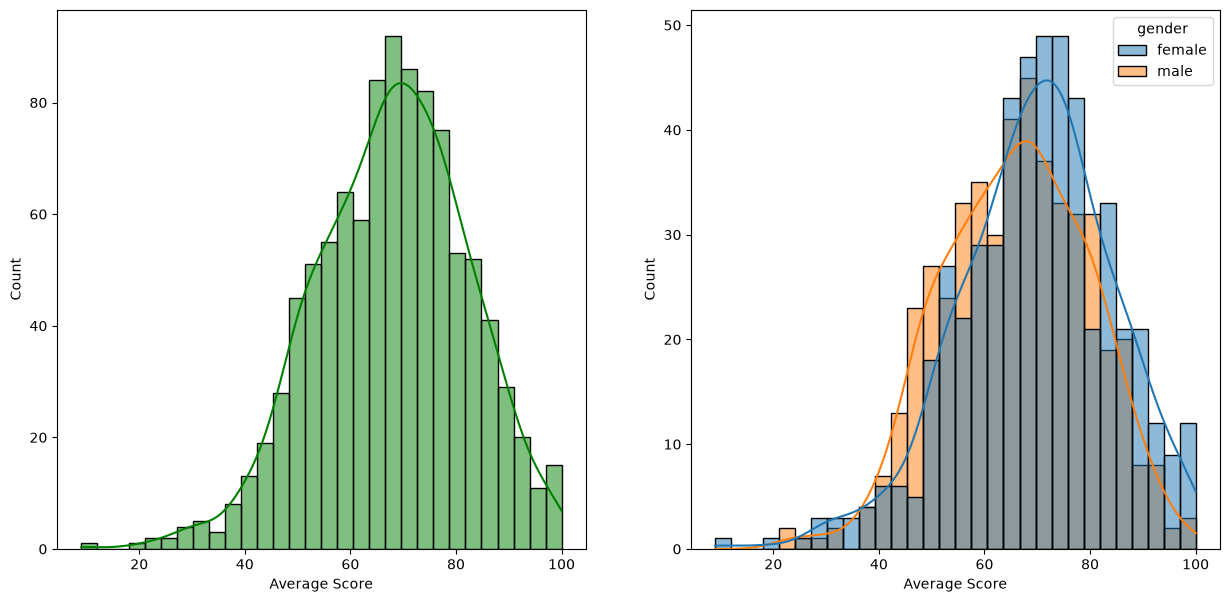

In [40]:
# Histogram and KDE plots for each score
fig, axes = plt.subplots(1,2,figsize=(15, 7))
plt.subplot(121)
sns.histplot(data = df , x = "Average Score",bins = 30 , kde = True,color = "green")
plt.subplot(122)
sns.histplot(data = df , x = "Average Score",bins = 30 , kde = True,hue = "gender")
plt.show()

In [37]:
# Insights : Female Students to perform better than Male Students

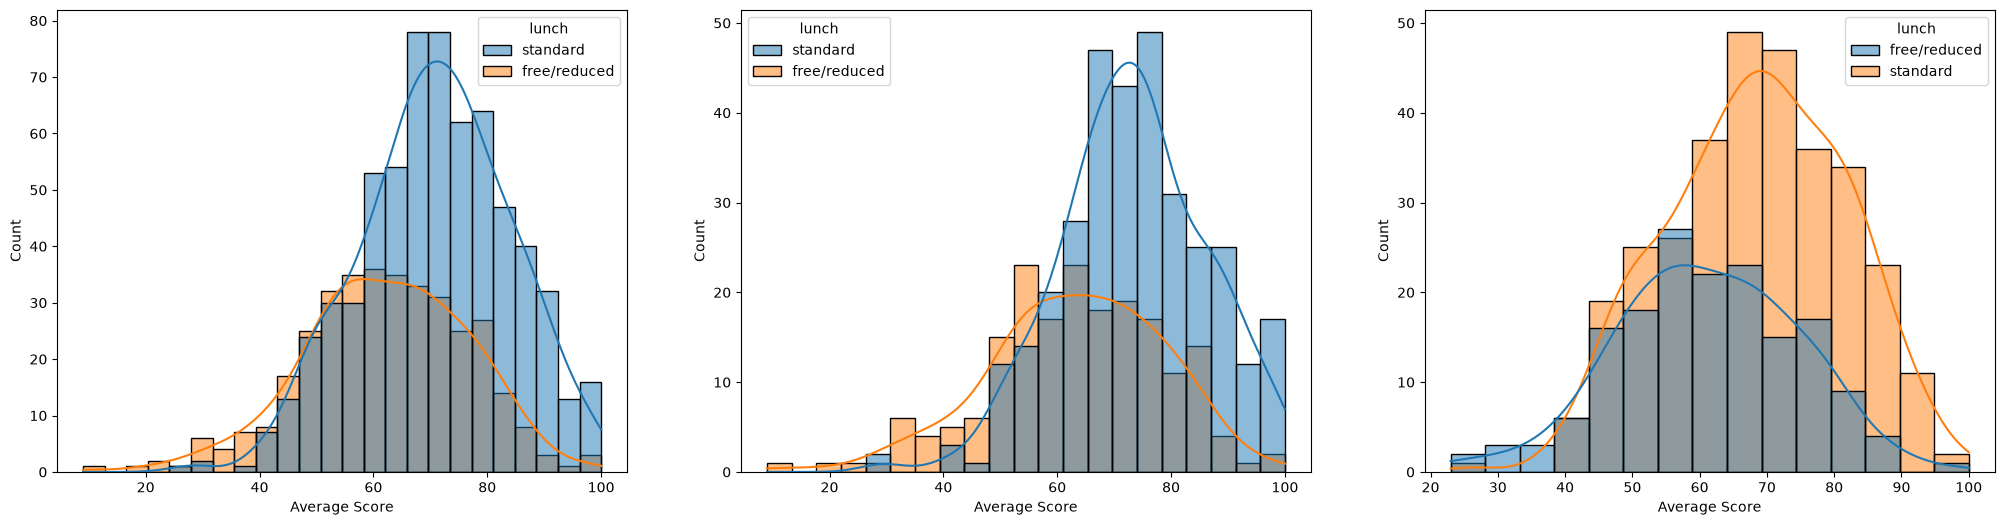

In [41]:
plt.subplots(1,3,figsize=(25, 6))
plt.subplot(131)
sns.histplot(data = df , x = "Average Score", kde = True,hue = "lunch")
plt.subplot(132)
sns.histplot(data = df[df.gender == "female"], x = "Average Score", kde = True,hue = "lunch")
plt.subplot(133)
sns.histplot(data = df[df.gender == "male"], x = "Average Score", kde = True,hue = "lunch")
plt.show()